# MNIST Handwritten Digit Recognition

## Internship Project – Machine Learning

### Objective
The objective of this project is to build a machine learning model that can recognize handwritten digits from 0 to 9 using the MNIST dataset.

## 1. Import Required Libraries

In [1]:
# Data handling
import numpy as np
import pandas as pd

# Data visualization
import matplotlib.pyplot as plt

# Machine learning
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Libraries imported successfully!")

Libraries imported successfully!


## 2. Load the MNIST Dataset

The MNIST dataset contains grayscale images of handwritten digits from 0 to 9. Each image has a size of 28 × 28 pixels.

The dataset will be loaded using Scikit-learn's `fetch_openml()` function.

In [3]:
from sklearn.datasets import fetch_openml

# Load MNIST dataset
mnist = fetch_openml(
    'mnist_784',
    version=1,
    as_frame=False,
    cache=True
)

X = mnist.data
y = mnist.target

print("MNIST dataset loaded successfully!")
print("Features shape:", X.shape)
print("Labels shape:", y.shape)

MNIST dataset loaded successfully!
Features shape: (70000, 784)
Labels shape: (70000,)


## 3. Understanding the MNIST Dataset

The MNIST dataset contains 70,000 grayscale images of handwritten digits from 0 to 9.

Each image has a resolution of 28 × 28 pixels. Since each image contains 784 pixels, the image data is stored as 784 numerical values.

The target variable contains the actual digit represented by each image.

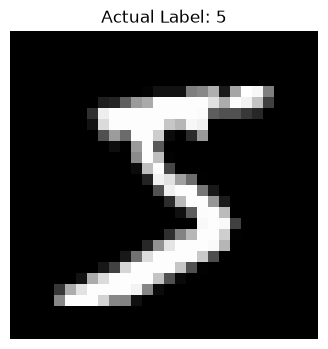

In [4]:
# Display the first image

plt.figure(figsize=(4, 4))

plt.imshow(X[0].reshape(28, 28), cmap='gray')

plt.title(f"Actual Label: {y[0]}")
plt.axis('off')

plt.show()

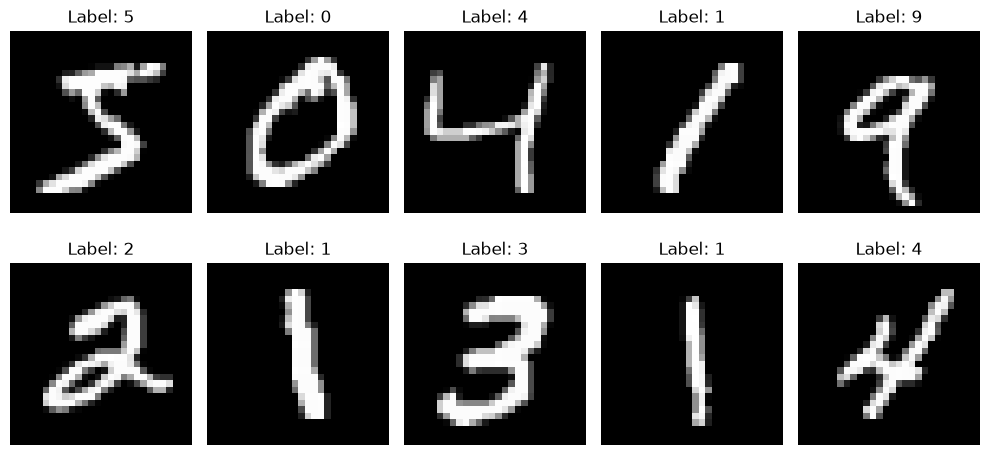

In [5]:
fig, axes = plt.subplots(2, 5, figsize=(10, 5))

for i, ax in enumerate(axes.ravel()):
    ax.imshow(X[i].reshape(28, 28), cmap='gray')
    ax.set_title(f"Label: {y[i]}")
    ax.axis('off')

plt.tight_layout()
plt.show()

## 4. Inspecting Pixel Values

Although the MNIST data represents images, the machine learning model receives numerical pixel values.

Each 28 × 28 grayscale image contains 784 pixel values. These values represent the intensity of each pixel.

In [6]:
# Check the pixel values of the first image

print("First image pixel values:")
print(X[0])

print("\nMinimum pixel value:", X[0].min())
print("Maximum pixel value:", X[0].max())

First image pixel values:
[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   3  18  18  18 126 136 175  26 166 255
 247 127   0   0   0   0   0   0   0   0   0   0   0   0  30  36  94 154
 170 253 253 253 253 253 225 172 253 242 195  64   0   0   0   0   0   0
   0   0   0   0   0  49 238 253 253 253 253 253 253 253 253 251  93  82
  82  56  39   0   0   0   0   0   0   0   0   0   0   0   0  18 219 253
 253 253 253 253 198 182 

## 5. Data Preprocessing

The pixel values in the MNIST dataset range from 0 to 255. To make the input values easier for the machine learning model to process, the pixel values are normalized to a range between 0 and 1.

Each pixel value is divided by 255.

In [7]:
# Convert pixel values to floating-point numbers
X = X.astype('float32')

# Normalize pixel values to the range 0 to 1
X = X / 255.0

print("Minimum pixel value:", X.min())
print("Maximum pixel value:", X.max())

Minimum pixel value: 0.0
Maximum pixel value: 1.0


## 6. Train-Test Split

The dataset is divided into training and testing sets. The training set is used to train the machine learning model, while the testing set is used to evaluate its performance on unseen images.

An 80/20 split is used, where 80% of the data is used for training and 20% for testing.

In [8]:
# Split the dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)

Training samples: 56000
Testing samples: 14000
Training features: (56000, 784)
Testing features: (14000, 784)


## 7. Train the Logistic Regression Model

Logistic Regression is a supervised machine learning classification algorithm. It is used here to classify handwritten images into one of the ten digit classes, from 0 to 9.

The model is trained using the normalized pixel values from the MNIST training dataset.

In [9]:
from sklearn.linear_model import LogisticRegression

# Create the Logistic Regression model
lr_model = LogisticRegression(
    max_iter=1000,
    solver='lbfgs'
)

# Train the model
lr_model.fit(X_train, y_train)



,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use i

## 8. Make Predictions

After training, the Logistic Regression model is used to predict the digit labels of the testing images.

The test data was not used during training, so it provides an unbiased way to evaluate how the model performs on unseen handwritten digits.

In [10]:
# Make predictions on the test dataset

y_pred = lr_model.predict(X_test)

print("Predictions generated successfully!")
print("Number of predictions:", len(y_pred))

Predictions generated successfully!
Number of predictions: 14000


## 9. Model Evaluation

Accuracy measures the percentage of test images that the model classified correctly.

It is calculated by comparing the actual digit labels with the predicted labels.

In [11]:
# Calculate accuracy

accuracy = accuracy_score(y_test, y_pred)

print("Logistic Regression Model Performance")
print("-" * 40)
print(f"Accuracy: {accuracy:.4f}")
print(f"Accuracy: {accuracy * 100:.2f}%")

Logistic Regression Model Performance
----------------------------------------
Accuracy: 0.9216
Accuracy: 92.16%


## 10. Classification Report

The classification report provides detailed performance metrics for each digit class from 0 to 9.

It includes precision, recall, and F1-score, which help us understand how well the model recognizes each individual digit.

In [12]:
report = classification_report(y_test, y_pred)

print("Classification Report")
print("-" * 60)
print(report)

Classification Report
------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.95      0.97      0.96      1381
           1       0.95      0.97      0.96      1575
           2       0.93      0.90      0.91      1398
           3       0.90      0.89      0.89      1428
           4       0.93      0.92      0.92      1365
           5       0.89      0.87      0.88      1263
           6       0.94      0.96      0.95      1375
           7       0.93      0.94      0.94      1459
           8       0.89      0.88      0.89      1365
           9       0.90      0.89      0.90      1391

    accuracy                           0.92     14000
   macro avg       0.92      0.92      0.92     14000
weighted avg       0.92      0.92      0.92     14000



## 11. Confusion Matrix

A confusion matrix shows the relationship between the actual digit labels and the predicted digit labels.

The rows represent the actual digits, while the columns represent the predicted digits. The diagonal values represent correctly classified images, while values outside the diagonal represent misclassifications.

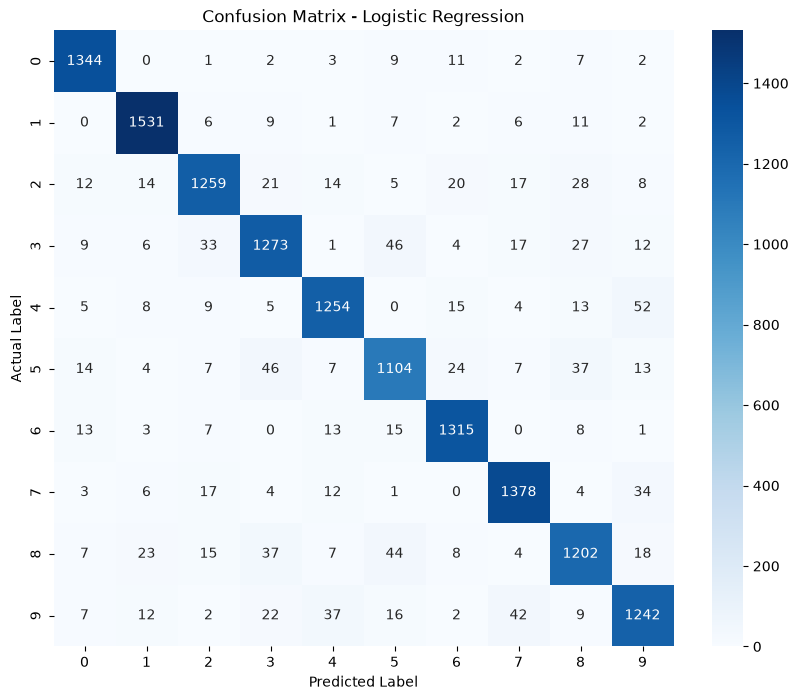

In [13]:
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=range(10),
    yticklabels=range(10)
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

## 12. Sample Predictions

A selection of test images is visualized with their actual and predicted labels. This provides a visual understanding of how the Logistic Regression model performs on individual handwritten digits.

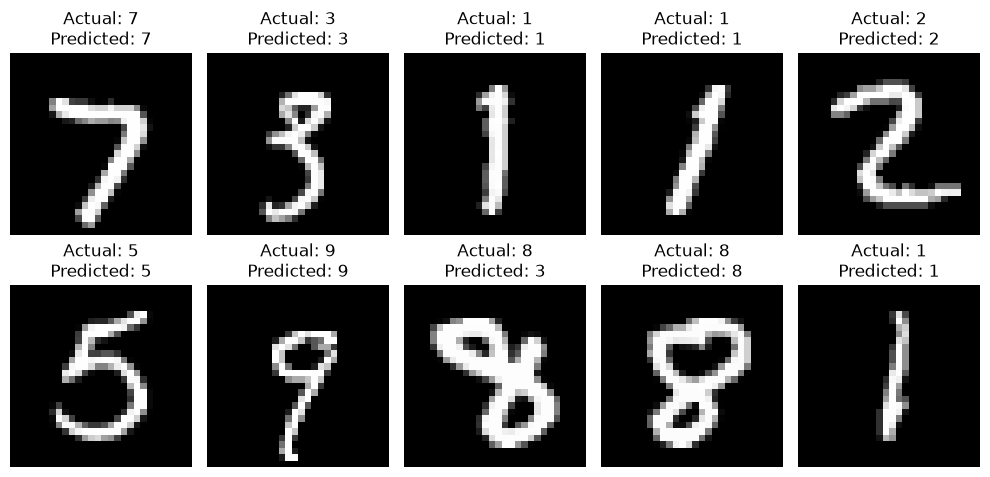

In [14]:
fig, axes = plt.subplots(2, 5, figsize=(10, 5))

for i, ax in enumerate(axes.ravel()):
    ax.imshow(X_test[i].reshape(28, 28), cmap='gray')
    ax.set_title(f"Actual: {y_test.iloc[i] if hasattr(y_test, 'iloc') else y_test[i]}\n"
                 f"Predicted: {y_pred[i]}")
    ax.axis('off')

plt.tight_layout()
plt.show()

## 13. Train the Random Forest Model

Random Forest is an ensemble machine learning algorithm that combines multiple decision trees to make predictions.

In this project, Random Forest is used as a second model for handwritten digit classification. Its performance will be compared with the Logistic Regression model.

In [15]:
from sklearn.ensemble import RandomForestClassifier

# Create the Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

# Train the model
rf_model.fit(X_train, y_train)



,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total

## 14. Make Random Forest Predictions

After training, the Random Forest model is used to predict the digit labels of the testing images.

The same testing dataset used for Logistic Regression is used here so that both models can be compared fairly.

In [16]:
# Generate predictions using Random Forest
y_pred_rf = rf_model.predict(X_test)

print("Random Forest predictions generated successfully!")
print("Number of predictions:", len(y_pred_rf))

Random Forest predictions generated successfully!
Number of predictions: 14000


## 15. Random Forest Model Evaluation

Accuracy measures the percentage of test images that the Random Forest model classified correctly.

The Random Forest accuracy will be compared with the Logistic Regression accuracy to understand the performance of both models.

In [17]:
rf_accuracy = accuracy_score(y_test, y_pred_rf)

print("Random Forest Model Performance")
print("-" * 40)
print(f"Accuracy: {rf_accuracy:.4f}")
print(f"Accuracy: {rf_accuracy * 100:.2f}%")

Random Forest Model Performance
----------------------------------------
Accuracy: 0.9672
Accuracy: 96.72%


## 16. Random Forest Classification Report

The classification report provides detailed performance metrics for each digit class from 0 to 9.

Precision, recall, and F1-score are used to evaluate how well the Random Forest model recognizes each individual digit.

In [18]:
rf_report = classification_report(y_test, y_pred_rf)

print("Random Forest Classification Report")
print("-" * 60)
print(rf_report)

Random Forest Classification Report
------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.97      0.99      0.98      1381
           1       0.98      0.98      0.98      1575
           2       0.96      0.97      0.97      1398
           3       0.96      0.96      0.96      1428
           4       0.97      0.96      0.96      1365
           5       0.97      0.96      0.96      1263
           6       0.97      0.98      0.98      1375
           7       0.97      0.97      0.97      1459
           8       0.96      0.96      0.96      1365
           9       0.94      0.94      0.94      1391

    accuracy                           0.97     14000
   macro avg       0.97      0.97      0.97     14000
weighted avg       0.97      0.97      0.97     14000



## 17. Random Forest Confusion Matrix

The confusion matrix shows the actual and predicted digit labels for the Random Forest model.

The diagonal values represent correctly classified images, while values outside the diagonal represent misclassified images.

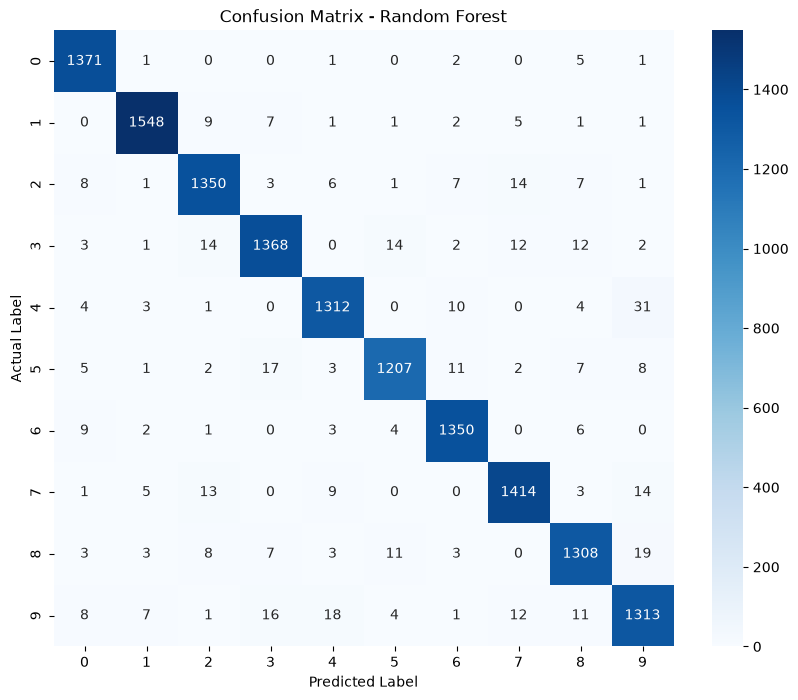

In [19]:
rf_cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(10, 8))

sns.heatmap(
    rf_cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=range(10),
    yticklabels=range(10)
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix - Random Forest")
plt.show()

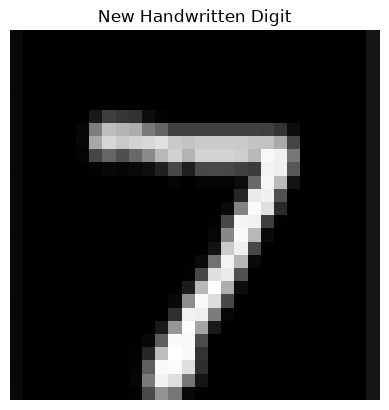

In [141]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# Path to your new handwritten digit image
image_path = "../images/download 7.png"

# Open image and convert it to grayscale
img = Image.open(image_path).convert("L")

# Resize image to MNIST size
img = img.resize((28, 28))

# Convert image to NumPy array
img_array = np.array(img)

# Display the image
plt.imshow(img_array, cmap="gray")
plt.title("New Handwritten Digit")
plt.axis("off")
plt.show()

In [ ]:
# Normalize pixel values


Image shape: (1, 784)
Minimum pixel value: 0.0
Maximum pixel value: 1.0


In [144]:
# Predict the digit using Random Forest
prediction = rf_model.predict(new_image)

print("Predicted Digit:", prediction[0])

Predicted Digit: 7


c:\Users\HP\Desktop\ARC Tech Internship\.venv\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
c:\Users\HP\Desktop\ARC Tech Internship\.venv\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
c:\Users\HP\Desktop\ARC Tech Internship\.venv\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
c:\Users\HP\Desktop\ARC Tech Internsh

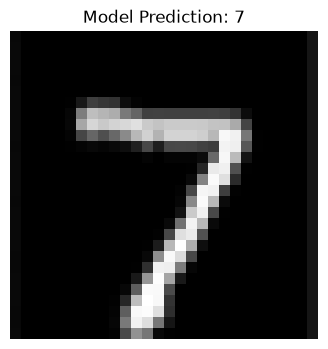

In [145]:
plt.figure(figsize=(4, 4))
plt.imshow(new_image.reshape(28, 28), cmap="gray")
plt.title(f"Model Prediction: {prediction[0]}")
plt.axis("off")
plt.show()

## 18. Model Comparison

The performance of Logistic Regression and Random Forest is compared using their accuracy scores.

Both models were trained and evaluated using the same MNIST training and testing datasets.

In [21]:
comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Accuracy': [accuracy, rf_accuracy]
})

comparison['Accuracy (%)'] = comparison['Accuracy'] * 100

print(comparison)

                 Model  Accuracy  Accuracy (%)
0  Logistic Regression  0.921571     92.157143
1        Random Forest  0.967214     96.721429


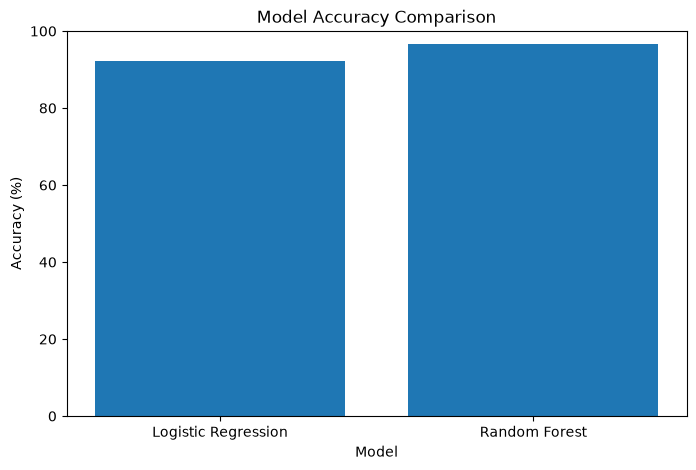

In [22]:
plt.figure(figsize=(8, 5))

plt.bar(
    comparison['Model'],
    comparison['Accuracy (%)']
)

plt.ylabel("Accuracy (%)")
plt.xlabel("Model")
plt.title("Model Accuracy Comparison")
plt.ylim(0, 100)

plt.show()

## 19. Conclusion

In this project, a machine learning system was developed to recognize handwritten digits from 0 to 9 using the MNIST dataset. The dataset was preprocessed by normalizing pixel values and dividing the data into training and testing sets.

Two machine learning models were trained and evaluated: Logistic Regression and Random Forest. Logistic Regression achieved an accuracy of 92.16%, while Random Forest achieved an accuracy of 96.72%.

The results show that both models were able to recognize handwritten digits, with Random Forest achieving a higher accuracy on the test dataset. The classification reports and confusion matrices were also used to analyze the performance of the models across individual digit classes.